# Cluster Analysis and Characterization

In [1]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from math import ceil

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans

from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, estimate_bandwidth

from sklearn.base import clone
from sklearn.metrics import pairwise_distances

## New imports
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
import graphviz

sns.set()

In [2]:
## Un-comment these if you want to use ydata_profiling

# !pip install -U ydata-profiling
# from ydata_profiling import ProfileReport


## Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below:
![Schema](https://raw.githubusercontent.com/fpontejos/DMDM_2223/main/figures/schema.png "Relation database schema")

## Reading the Data

In [3]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [5]:
## Load csv file into a dataframe
## Alternative location of the csv file

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"

## df = pd.read_csv(data_path)

### Make a copy of your original dataset

why?

In [6]:
df_original = df.copy()

### Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Preprocess the Data

Remember what we did in the previous session

In [7]:
# Sometimes it is not obvious that a value is missing
# For example if the value is an empty string

# replace "" by nans
df.replace("", np.nan, inplace=True)

In [8]:
# Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]

## This is saying that the metric features are all the other features that are not non-metric
## Need to be careful in case not all columns are to be used as features

# metric_features = df.columns.drop(non_metric_features).to_list()

## Or you can also specify manually
metric_features = ['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

### Fill missing values (Data imputation)

How can we fill missing values?


#### Using measures of central tendency

In [9]:
# Creating a copy to apply central tendency measures imputation
df_central = df.copy()

In [10]:
# count of missing values
df_central.isna().sum()

Unnamed: 0            0
age                   0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          282
per_net_purchase      0
gender                0
education            47
status              177
description           0
dtype: int64

In [11]:
medians = df_central[metric_features].median()
medians

age                  1966.0
income              70030.5
frq                    17.0
rcn                    53.0
mnt                   383.0
clothes                51.0
kitchen                 4.0
small_appliances       28.0
toys                    4.0
house_keeping           4.0
per_net_purchase       45.0
dtype: float64

In [12]:
modes = df_central[non_metric_features].mode().loc[0]
modes

education      Graduation
status            Married
gender                  M
dependents            1.0
description      OK nice!
Name: 0, dtype: object

In [13]:
## Fill NaNs using medians and modes

df_central.fillna(medians, inplace=True)
df_central.fillna(modes, inplace=True)

In [14]:
df_central.isna().sum()  # checking how many NaNs we still have

Unnamed: 0          0
age                 0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
dependents          0
per_net_purchase    0
gender              0
education           0
status              0
description         0
dtype: int64

In [15]:
df = df_central.copy()

### Outlier removal

In [16]:
def remove_outliers(df, filters):

  df_2 = df[filters]
  print('Percentage of data kept after removing outliers:', 100*(np.round(df_2.shape[0] / df.shape[0], 4)))

  return df_2



In [17]:
# This may vary from session to session, and is prone to varying interpretations.
# A simple example is provided below:

manual_filters = (
    (df['house_keeping']<=50)
    &
    (df['kitchen']<=40)
    &
    (df['toys']<=35)
    &
    (df['education']!='OldSchool')
)

df_1 = remove_outliers(df, manual_filters)

Percentage of data kept after removing outliers: 97.99


In [18]:
# Get the manual filtering version
df = df_1.copy()

In [19]:
# How can we avoid having as many extreme values in 'rcn'?
print((df['rcn']>100).value_counts())

rcn_t = df['rcn'].copy()
rcn_t.loc[rcn_t>100] = 100

df['rcn'] = rcn_t

False    8437
True      380
Name: rcn, dtype: int64


#### What about non-metric features?

In [20]:
# Let's also remove status=Whatever
df.loc[df['status'] == 'Whatever', 'status'] = df['status'].mode()[0]


### Feature Engineering and Feature Selection

In [21]:
df['birth_year'] = df['age']
df['age'] = datetime.now().year - df['birth_year']

df['spent_online'] = (df['per_net_purchase'] / 100) * df['mnt']

#### Redundancy


In [22]:
# Select variables according to their correlations
df.drop(columns=['birth_year', 'age', 'mnt'], inplace=True)

In [23]:
# Updating metric_features
metric_features.append("spent_online")
metric_features.remove("mnt")
metric_features.remove("age")

In [24]:
metric_features

['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

#### Relevancy
Selecting variables based on the relevancy of each one to the task. Example: remove uncorrelated variables with the target, stepwise regression, use variables for product clustering, use variables for socio-demographic clustering, ...

Variables that aren't correlated with any other variable are often also not relevant. In this case we will not focus on this a lot since we don't have a defined task yet.

### Data Normalization

#### Standard Scaling

In [25]:
df_standard = df.copy()

In [26]:
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(df_standard[metric_features])
df_standard[metric_features] = scaled_feat


In [27]:
df = df_standard.copy()

### One-hot encoding

In [28]:
df_ohc = df.copy()

In [29]:
def get_ohc_df(df, feats):
  # Use OneHotEncoder to encode the categorical features.
  # Get feature names and create a DataFrame
  # with the one-hot encoded categorical features (pass feature names)

  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  # Reassigning df to contain ohc variables
  df_ohc = pd.concat([df, ohc_df], axis=1)

  ## Return the df with the one-hot encoded features
  ## Also return the OneHotEncoder model (ohc)
  return df_ohc, ohc

df_ohc, ohc = get_ohc_df(df, non_metric_features)


In [30]:
oh_features = ohc.get_feature_names_out().tolist()
oh_features

['education_2nd Cycle',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'status_Married',
 'status_Single',
 'status_Together',
 'status_Widow',
 'gender_M',
 'dependents_1.0',
 'description_Kind of OK',
 'description_Meh...',
 'description_OK nice!',
 'description_Take my money!!']

In [31]:
df_ohc.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!'],
      dtype='object')

In [32]:
df = df_ohc.copy()

## Remove noise rows with DBSCAN


In [33]:
def split_noise_rows(df, feats, dbs_model):
  ## Splits the dataframe into noise and non-noise
  dbscan_labels = dbs_model.fit_predict(df[feats])

  df_concat = pd.concat([df,
                            pd.Series(dbscan_labels,
                                      name='dbscan_labels',
                                      index=df.index)], axis=1)

  df_noise = df_concat[df_concat['dbscan_labels']==-1].copy()
  df_nonoise = df_concat[df_concat['dbscan_labels']==0].copy()


  return df_noise, df_nonoise, df_concat

In [34]:
## Refer to previous notebook for how to tune DBSCAN
## Based on the hyperparameters we found

dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=4)

df_noise, df_nonoise, df_combined_noise = split_noise_rows(df, metric_features, dbscan)

In [35]:
## Rename df_nonoise dataframe to df for simplicity
## Remember the df_combined_noise dataframe has both noise and non noise rows

print(df_combined_noise.shape)
print(df_nonoise.shape)
print(df_noise.shape)

df = df_nonoise.copy()



(8817, 31)
(8715, 31)
(102, 31)


## Clustering by Perspectives

In [36]:
## Split variables into perspectives
## This is an example; requires critical thinking and some domain knowledge

demographic_features = [
    'income',
    'frq',
    'per_net_purchase',
    'spent_online'
]

preference_features = [
    'clothes',
    'kitchen',
    'small_appliances',
    'toys',
    'house_keeping',
]

df_dem = df[demographic_features].copy()
df_prf = df[preference_features].copy()

### Apply clustering by perspectives

In [37]:
perspective_1 = 'pref_labels'
perspective_2 = 'demog_labels'

In [38]:
kmeans_pref = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)
pref_labels = kmeans_pref.fit_predict(df_prf)

df['pref_labels'] = pref_labels


In [39]:
# Applying the right clustering (algorithm and number of clusters) for each perspective

kmeans_dem = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)
demog_labels = kmeans_dem.fit_predict(df_dem)

df['demog_labels'] = demog_labels

In [40]:
# Count label frequencies (contigency table)

def make_contingency_table(df, label1, label2):
  df_ = df.groupby([label1, label2])\
            .size()\
            .to_frame()\
            .reset_index()\
            .pivot(index=label2, columns=label1)
  df_.columns = df_.columns.droplevel()
  return df_



In [41]:
make_contingency_table(df, perspective_1, perspective_2)


pref_labels,0,1,2
demog_labels,,,
0,1336,639,207
1,707,247,43
2,388,1233,291
3,1153,1458,1013


#### Merge using Hierarchical Clustering

In [42]:
def get_mean_bylabel(df, feats, label_name):
  # Characterizing the clusters
  return df[feats+[label_name]].groupby(label_name).mean()


In [43]:
# Centroids of the concatenated cluster labels
df_hc_centroids = df.groupby([perspective_1, perspective_2])[metric_features].mean()
df_hc_centroids

income       frq       rcn   clothes   kitchen  \
pref_labels demog_labels                                                     
0           0             0.140280 -0.080496 -0.075931  1.052776 -0.576134   
            1             0.693508  1.131881 -0.045360  1.099258 -0.601391   
            2             1.129881  1.207185  0.003192  0.738408 -0.524402   
            3            -0.621136 -0.884314  0.057295  0.951003 -0.603964   
1           0             0.203474 -0.114649 -0.093395 -0.245723 -0.052970   
            1             0.935409  1.306561 -0.022407 -0.206583 -0.048124   
            2             1.225127  1.217530 -0.084086 -0.468884 -0.080535   
            3            -0.938724 -0.866872  0.115945 -0.460022 -0.060958   
2           0             0.223129 -0.240270 -0.131415 -0.858325  1.193569   
            1             0.869229  1.025457 -0.091564 -0.717197  1.073944   
            2             1.191136  0.953649  0.011270 -1.098774  1.210396   
            3            -1.328229 -0.913881  0.091910 -1.432161  1.541292   

                          small_appliances      toys  house_keeping  \
pref_labels demog_labels                                              
0           0                    -0.923965 -0.592796      -0.569859   
            1                    -0.958321 -0.621980      -0.603579   
            2                    -0.464818 -0.502588      -0.503376   
            3                    -0.695984 -0.606959      -0.601078   
1           0                     0.465742  0.012613       0.017145   
            1                     0.457913 -0.040265      -0.048750   
            2                     0.950322 -0.029960      -0.051247   
            3                     0.912056 -0.049288      -0.013862   
2           0                    -0.261014  1.127126       0.866784   
            1                    -0.300932  0.792654       0.935015   
            2                     0.246073  1.084451       0.773731   
            3                     0.021500  1.500632       1.465216   

                          per_net_purchase  spent_online  
pref_labels demog_labels                                  
0           0                     0.093666      0.164015  
            1                     0.205066      2.073131  
            2                    -1.291168      0.466297  
            3                     0.654463     -0.763638  
1           0                    -0.250912      0.051536  
            1                    -0.101336      2.043056  
            2                    -1.465394      0.288564  
            3                     0.830015     -0.789210  
2           0                    -0.359403     -0.077162  
            1                    -0.187964      1.634177  
            2                    -1.425837      0.189875  
            3                     0.771821     -0.857517

In [44]:
## Map combinations of the two labels to their merged cluster label

def hc_merge_mapper(df, label1, label2, feats, merged_label, n_clusters=1):
  df_ = df.copy()

  # Centroids of the concatenated cluster labels
  df_centroids = df_.groupby([label1, label2])[feats].mean()

  # Re-running the Hierarchical clustering based on the correct number of clusters
  hclust = AgglomerativeClustering(
      linkage='ward',
      metric='euclidean',
      n_clusters=n_clusters
  )
  hclust_labels = hclust.fit_predict(df_centroids)
  df_centroids[merged_label] = hclust_labels

  cluster_mapper = df_centroids[merged_label].to_dict()

  # Mapping the clusters on the centroids to the observations
  df_[merged_label] = df_.apply(
      lambda row: cluster_mapper[
          (row[label1], row[label2])
      ], axis=1
  )

  return df_, df_centroids


In [45]:
df_hc_merged, df_hc_centroids = hc_merge_mapper(df, perspective_1, perspective_2, metric_features, 'hc_merged_labels', 7)


In [46]:
df_hc_merged['hc_merged_labels'].value_counts()

5    2489
2    2097
0    1621
3    1013
6     707
4     498
1     290
Name: hc_merged_labels, dtype: int64

In [47]:
## Get final DF
df = df_hc_merged.copy()

## Cluster Characterization

In [48]:
df.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!', 'dbscan_labels', 'pref_labels',
       'demog_labels', 'hc_merged_labels'],
      dtype='object')

### Cluster Profiles

In [49]:
def cluster_profiles(df,
                     label_columns,
                     figsize,
                     compar_titles=None,
                     colors='Set1'):
    """
    Pass df with labels columns of one or multiple clustering labels.
    Then specify this label columns to perform the cluster profile according to them.
    """
    if compar_titles == None:
        compar_titles = [""]*len(label_columns)

    fig, axes = plt.subplots(nrows=len(label_columns), ncols=2,
                             figsize=figsize, squeeze=False)
    for ax, label, titl in zip(axes, label_columns, compar_titles):

        # Filtering df
        drop_cols = [i for i in label_columns if i!=label]
        dfax = df.drop(drop_cols, axis=1)

        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:,[0,1]]
        counts.columns = [label, "counts"]

        # Setting Data
        pd.plotting.parallel_coordinates(centroids, label,
                                         color=sns.color_palette(palette=colors), ax=ax[0])
        sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
                    palette=sns.color_palette(palette=colors))

        #Setting Layout
        handles, _ = ax[0].get_legend_handles_labels()
        cluster_labels = ["Cluster {}".format(i) for i in range(len(handles))]
        ax[0].annotate(text=titl, xy=(0.95,1.1), xycoords='axes fraction', fontsize=13, fontweight = 'heavy')
        ax[0].legend(handles, cluster_labels) # Adaptable to number of clusters
        ax[0].axhline(color="black", linestyle="--")
        ax[0].set_title("Cluster Means - {} Clusters".format(len(handles)), fontsize=13)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-20)
        ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
        ax[1].set_xticklabels(cluster_labels)
        ax[1].set_xlabel("")
        ax[1].set_ylabel("Absolute Frequency")
        ax[1].set_title("Cluster Sizes - {} Clusters".format(len(handles)), fontsize=13)

    plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.suptitle("Cluster Simple Profilling", fontsize=23)
    plt.show()

In [50]:
# Reminder:
# perspective_1 = 'pref_labels'
# perspective_2 = 'demog_labels'

merged_label_name = 'hc_merged_labels'

In [51]:
labels_list = [perspective_2, perspective_1, merged_label_name]

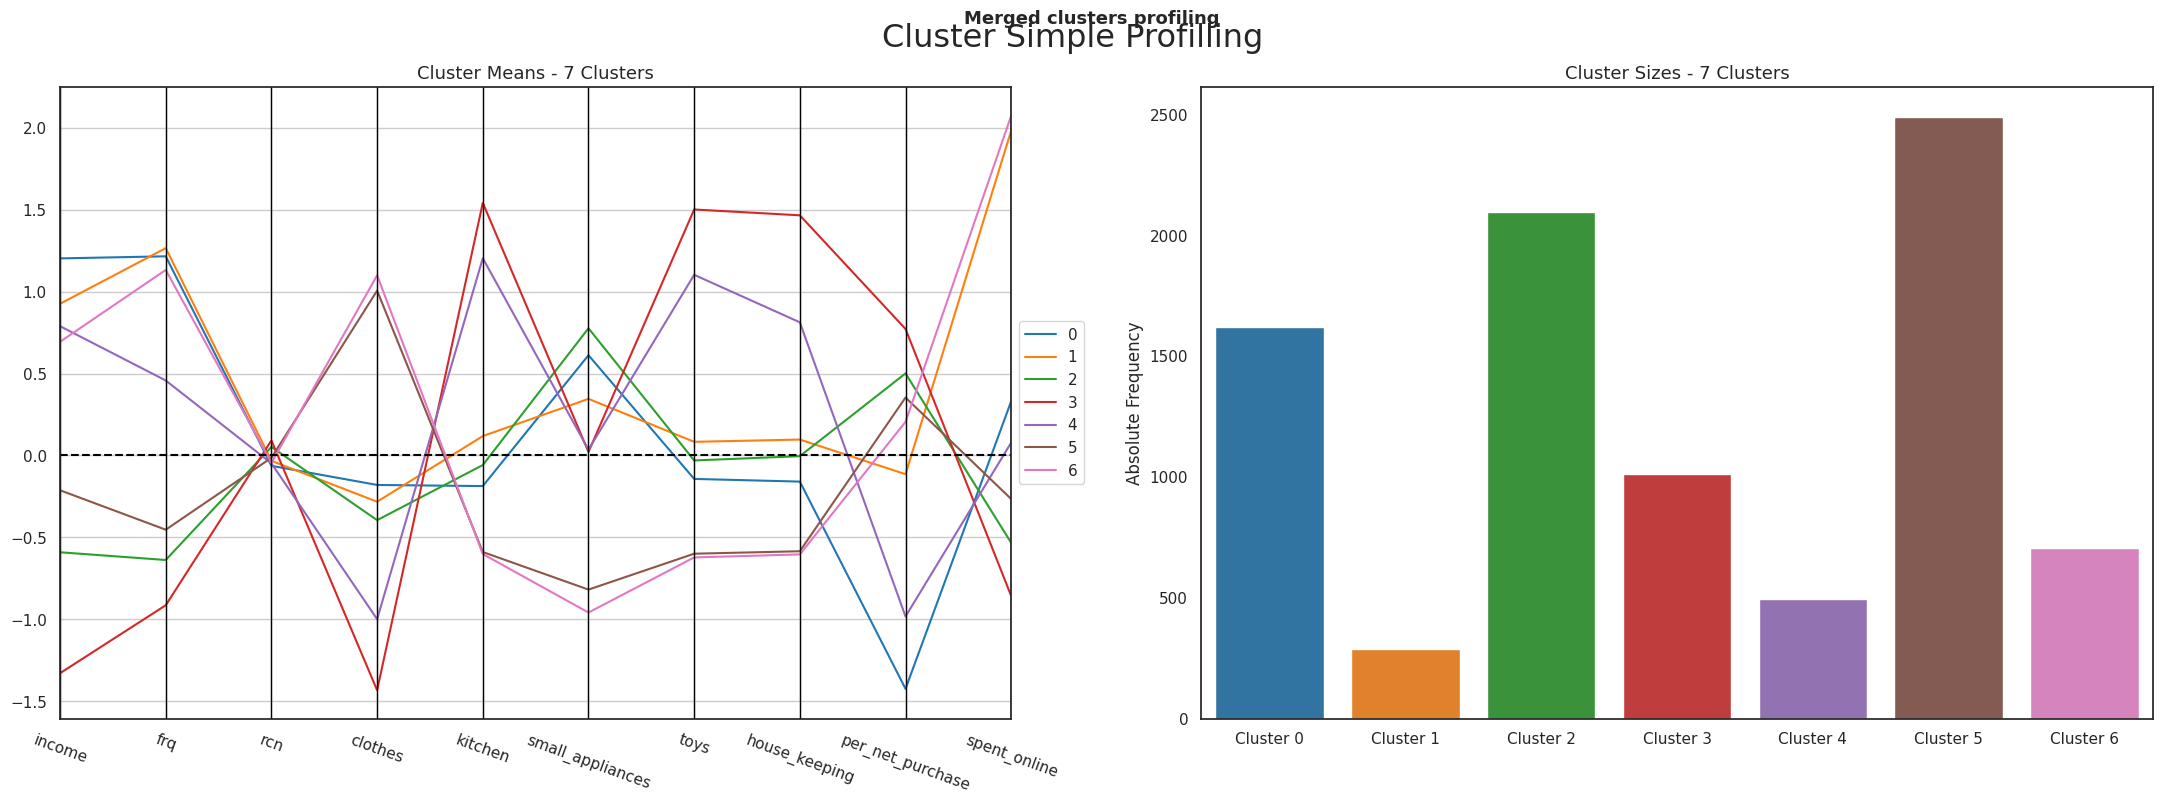

In [52]:
# Profilling each cluster (only merged)
merged_label_list = [merged_label_name]
sns.set(style="white")
cluster_profiles(
    df = df[metric_features + merged_label_list],
    label_columns = merged_label_list,
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    colors='tab10'
)


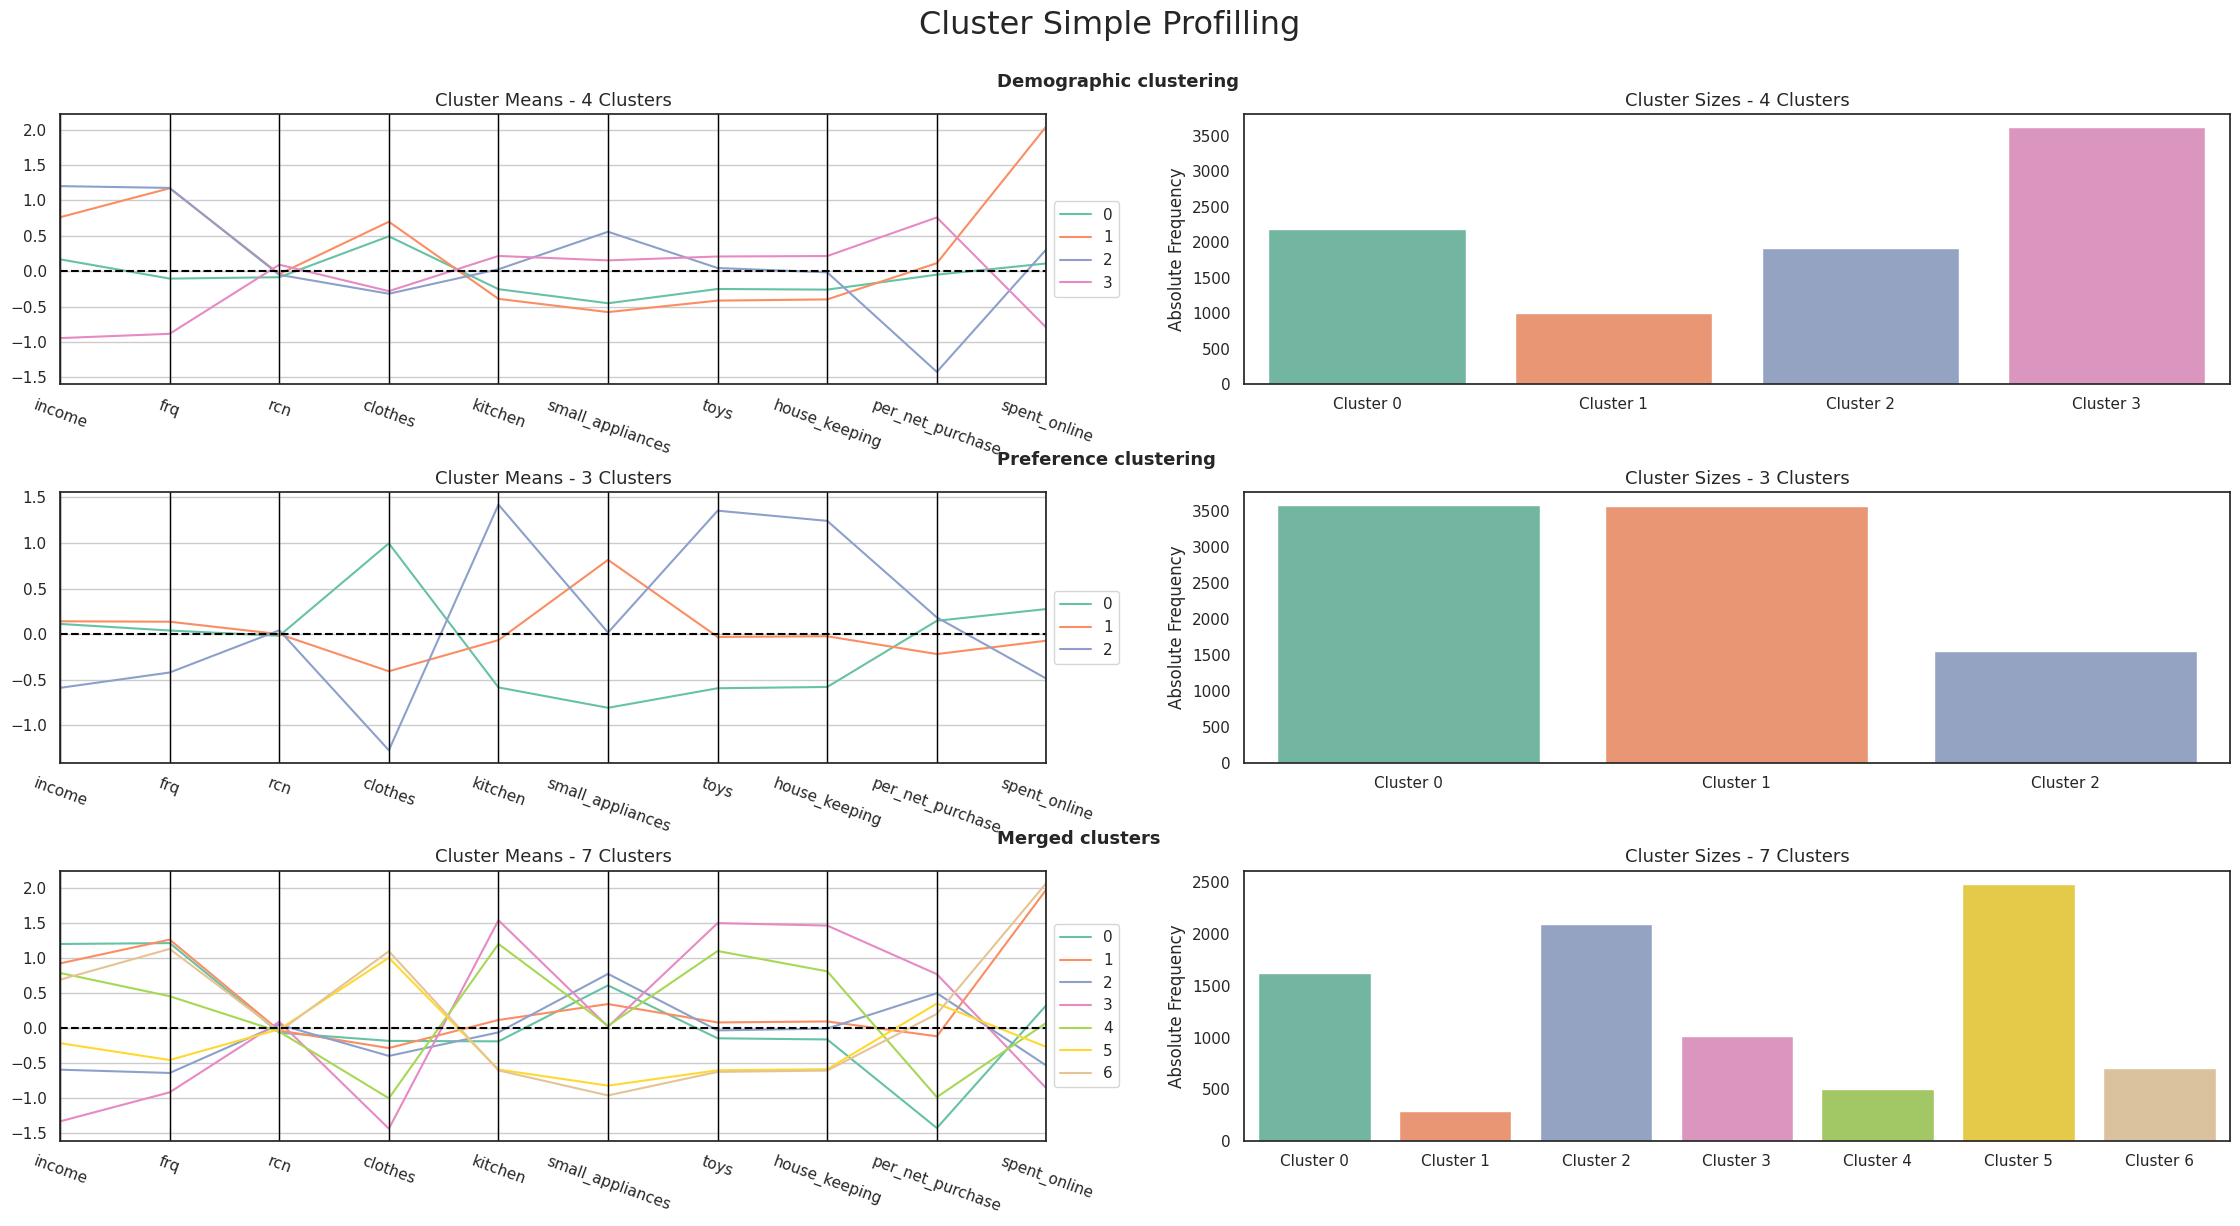

In [53]:
# Profilling each cluster (product, behavior, merged)
sns.set(style="white")
cluster_profiles(
    df = df[metric_features + labels_list],
    label_columns = labels_list,
    figsize = (28, 13),
    compar_titles = ["Demographic clustering", "Preference clustering", "Merged clusters"],
    colors='Set2'
)


## Visualize profiles using heatmaps

In [54]:
def cluster_heatmaps(df,
                     label_columns,
                     figsize=(20,20),
                     compar_titles=None,
                     heat_colors='RdYlBu',
                     bar_colors='Set2'):
    """
    Pass df with labels columns of one or multiple clustering labels.
    Then specify this label columns to perform the cluster profile according to them.
    """
    if compar_titles == None:
        compar_titles = [""]*len(label_columns)

    fig, axes = plt.subplots(nrows=len(label_columns), ncols=2,
                             figsize=figsize, squeeze=False)
    for ax, label, titl in zip(axes, label_columns, compar_titles):

        # Filtering df
        drop_cols = [i for i in label_columns if i!=label]
        dfax = df.drop(drop_cols, axis=1)

        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:,[0,1]]
        counts.columns = [label, "counts"]


        # Setting Data
        handles, _ = ax[0].get_legend_handles_labels()
        cluster_labels = ["Cluster {}".format(i) for i in range(counts.shape[0])]

        sns.heatmap(centroids.drop(columns=label),
              square=False, cmap=heat_colors,
              ax=ax[0],
              )

        ax[0].set_title("Cluster Means Heatmap - {} Clusters".format(counts.shape[0]), fontsize=18)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-20)
        ax[0].set_yticklabels(cluster_labels, rotation=0)
        ax[1].annotate(text=titl, xy=(-0.3,1.15),
                       xycoords='axes fraction',
                       fontsize=18, fontweight = 'heavy')


        sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
        ax[1].set_yticklabels(cluster_labels)
        ax[1].set_title("Cluster Sizes - {} Clusters".format(counts.shape[0]), fontsize=18)
        ax[1].set_ylabel("")

    plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.suptitle("Cluster Simple Profilling", fontsize=23)
    plt.show()

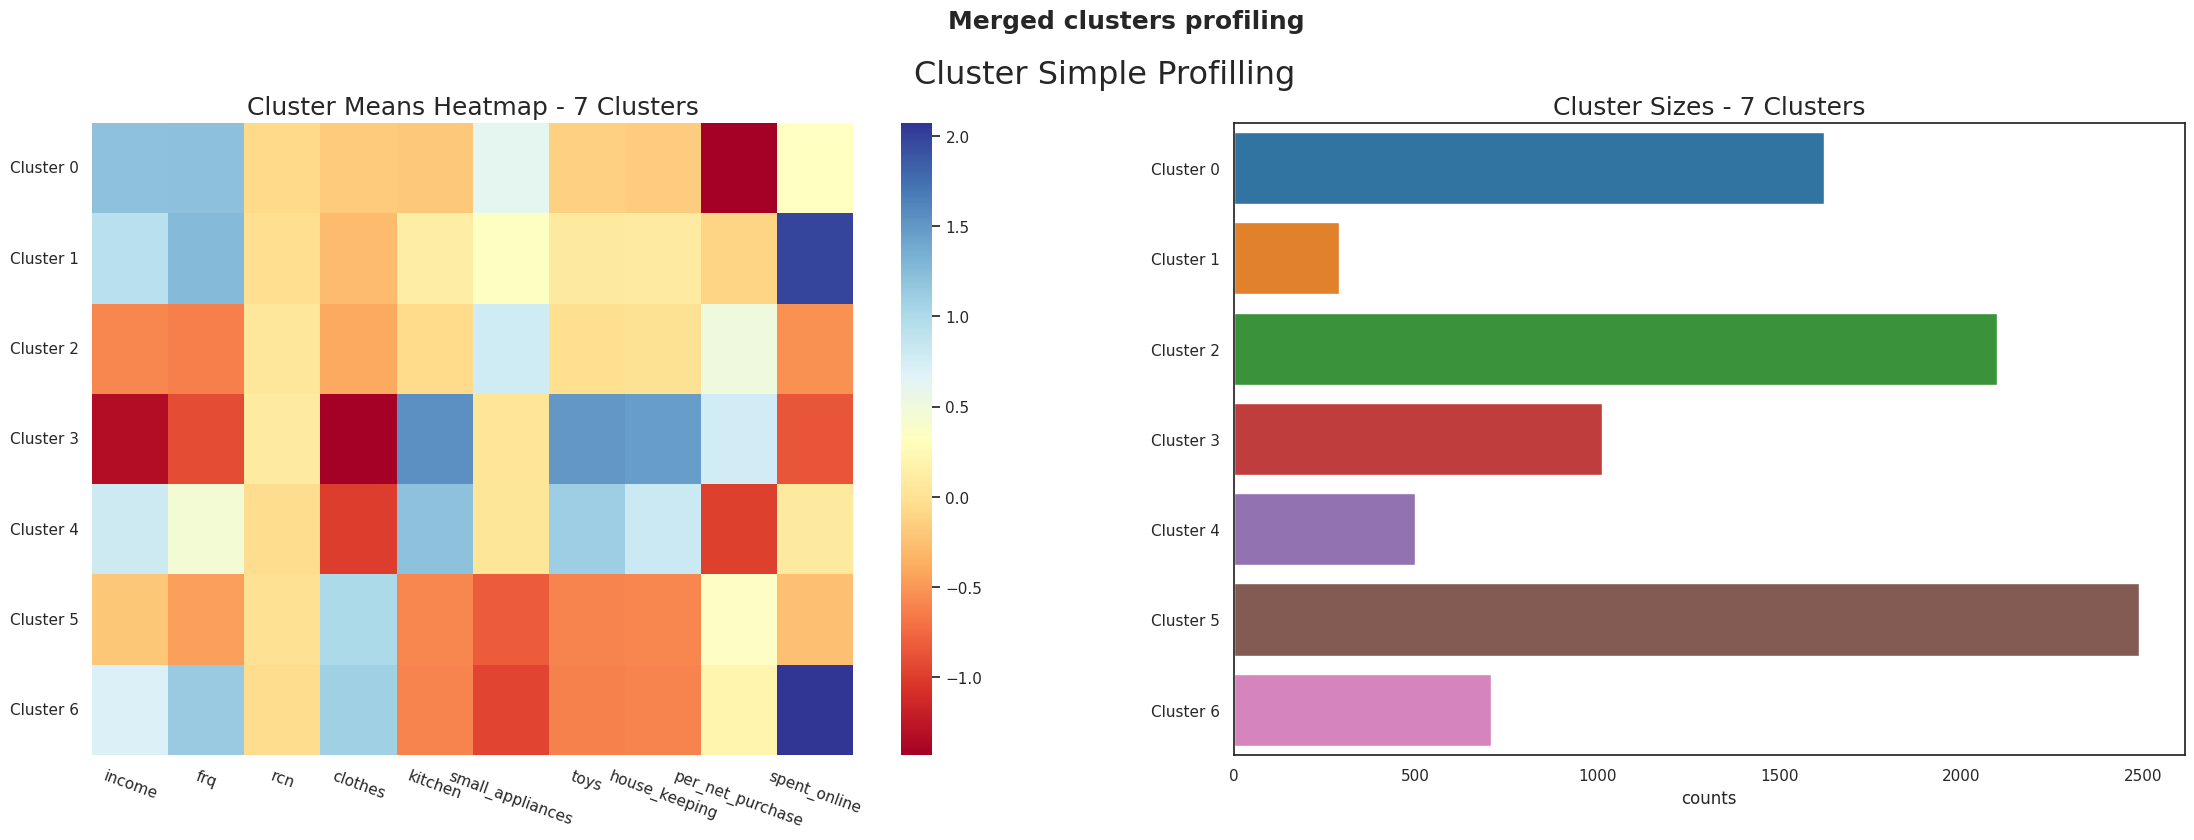

In [55]:

# Profilling each cluster (only merged)
merged_label_list = [merged_label_name]
sns.set(style="white")
cluster_heatmaps(
    df = df[metric_features + merged_label_list],
    label_columns = merged_label_list,
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    bar_colors='tab10'
)

sns.set()


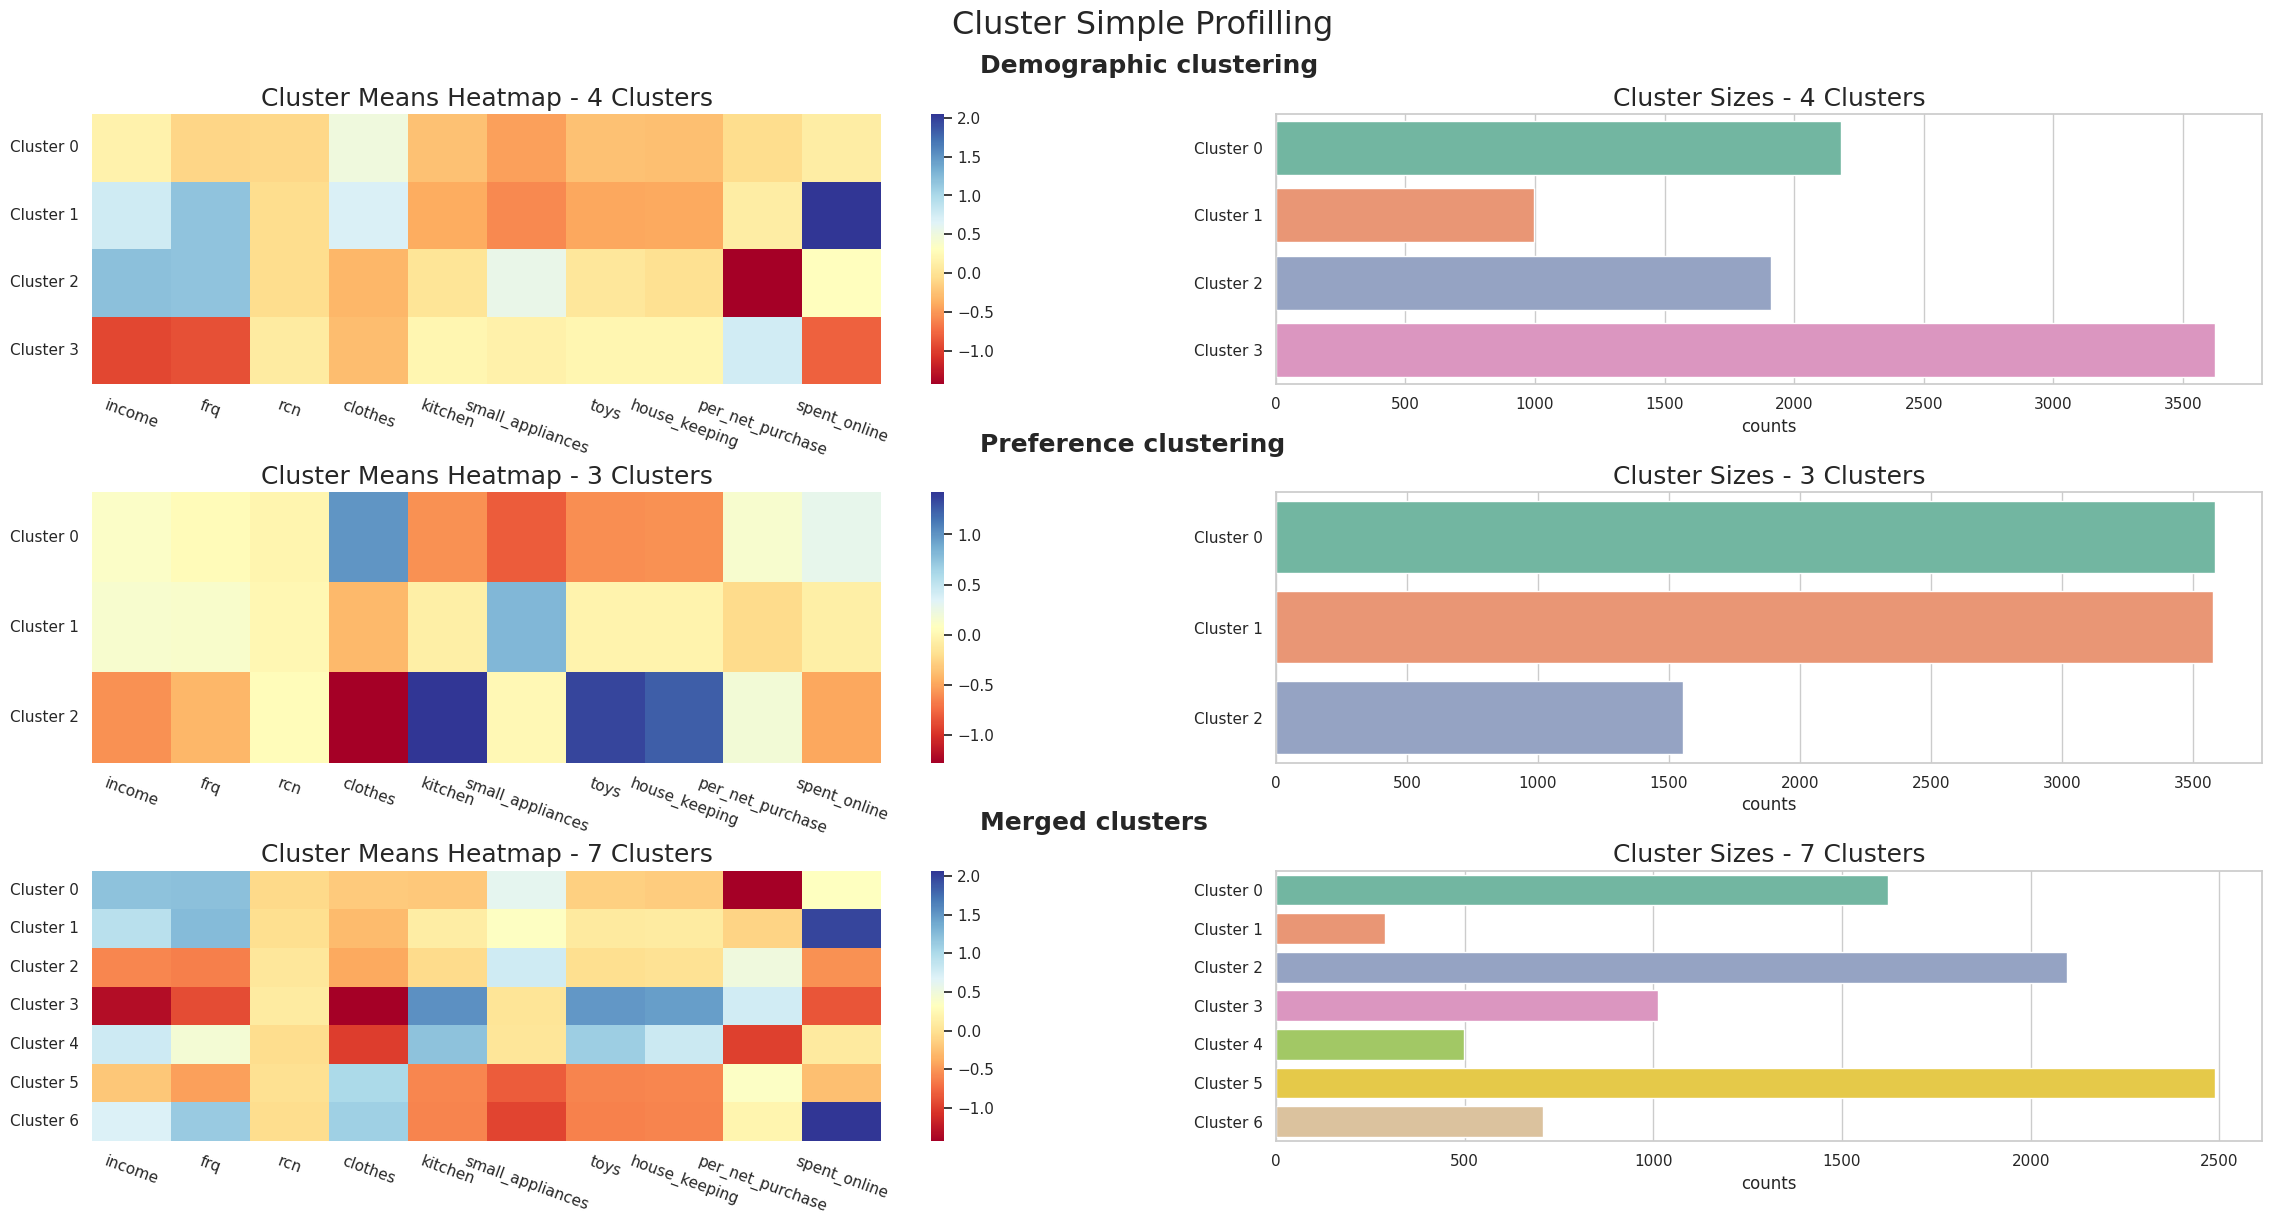

In [56]:
# Profilling each cluster (product, behavior, merged)
sns.set(style="whitegrid")
cluster_heatmaps(
    df = df[metric_features + labels_list],
    label_columns = labels_list,
    figsize = (28, 13),
    compar_titles = ["Demographic clustering", "Preference clustering", "Merged clusters"],
)


## Tabular cluster characterization

### Recover original values

Remember, we scaled our data during preprocessing

In [57]:
## Check the variable name of the scaler you chose to use

scaler

StandardScaler()

In [58]:
scaled_feature_names = scaler.get_feature_names_out()
scaled_feature_names


array(['income', 'frq', 'rcn', 'clothes', 'kitchen', 'small_appliances',
       'toys', 'house_keeping', 'per_net_purchase', 'spent_online'],
      dtype=object)

In [59]:
## Get the inverse of the transformed values
pd.DataFrame(scaler.inverse_transform(df[scaled_feature_names]),
             columns=scaled_feature_names)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
0,90782.0,33.0,66.0,37.0,5.0,44.0,10.0,3.0,19.0,266.38
1,113023.0,32.0,6.0,55.0,1.0,38.0,4.0,2.0,9.0,138.33
2,28344.0,11.0,69.0,32.0,19.0,24.0,1.0,24.0,59.0,25.96
3,93571.0,26.0,10.0,60.0,10.0,19.0,6.0,5.0,35.0,310.80
4,91852.0,31.0,26.0,59.0,5.0,28.0,4.0,4.0,34.0,386.92
...,...,...,...,...,...,...,...,...,...,...
8710,87399.0,25.0,1.0,56.0,8.0,27.0,8.0,1.0,47.0,393.39
8711,94367.0,28.0,1.0,68.0,5.0,21.0,3.0,4.0,55.0,492.80
8712,58121.0,12.0,6.0,53.0,6.0,28.0,7.0,6.0,71.0,43.31
8713,54292.0,29.0,72.0,41.0,11.0,36.0,1.0,11.0,31.0,313.41


In [60]:
## Put this into a DF

df_unscaled = df.copy()

df_unscaled[scaled_feature_names] = pd.DataFrame(scaler.inverse_transform(df[scaled_feature_names]),
                           index=df.index)

df_unscaled.head()

,Unnamed: 0,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!,dbscan_labels,pref_labels,demog_labels,hc_merged_labels
0,0,90782.0,33.0,66.0,37.0,5.0,44.0,10.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0,1,2,0
1,1,113023.0,32.0,6.0,55.0,1.0,38.0,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,1,2,0
2,2,28344.0,11.0,69.0,32.0,19.0,24.0,1.0,24.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0,2,3,3
3,3,93571.0,26.0,10.0,60.0,10.0,19.0,6.0,5.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0,5
4,4,91852.0,31.0,26.0,59.0,5.0,28.0,4.0,4.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0,0,1,6


In [61]:
cluster_means = get_mean_bylabel(df_unscaled,
                                 metric_features,
                                 merged_label_name)

cluster_means.style.format(precision=2).background_gradient(axis=0)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
hc_merged_labels,,,,,,,,,,
0,103292.13,33.26,50.32,47.05,5.41,36.38,5.59,5.56,15.93,234.19
1,95752.46,33.80,51.24,44.69,7.64,33.02,7.16,7.50,40.13,512.55
2,54441.38,13.03,53.79,42.11,6.35,38.45,6.37,6.73,51.49,88.53
3,34346.49,10.01,54.99,18.27,18.04,28.94,16.93,17.81,56.51,33.83
4,92024.65,24.98,50.78,28.22,15.57,29.12,14.18,12.89,24.08,191.67
5,64746.50,15.05,51.79,74.29,2.47,18.37,2.45,2.36,48.77,133.59
6,89429.19,32.35,50.86,76.45,2.38,16.60,2.29,2.21,46.03,527.84


In [62]:
## Do the same with pref_labels and demog_labels instead of merged_labels


In [63]:
cluster_means_1 = get_mean_bylabel(df_unscaled,
                                 metric_features,
                                 perspective_1)
cluster_means_1
# cluster_means_1.style.format(precision=2).background_gradient(axis=0)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
pref_labels,,,,,,,,,,
0,73574.764230,20.421317,51.664900,74.053292,2.504185,18.501116,2.490234,2.396205,44.941964,224.719149
1,74365.535085,21.476097,52.222253,41.820240,6.298854,38.928152,6.367906,6.586245,38.200727,166.252519
2,54486.867439,15.396396,53.484556,21.911840,17.158301,28.888031,15.912484,16.123552,45.624196,96.034003


In [64]:
cluster_means_2 = get_mean_bylabel(df_unscaled,
                                 metric_features,
                                 perspective_2)

cluster_means_2.round(2)
# cluster_means_2.style.format(precision=2).background_gradient(axis=0)


,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
demog_labels,,,,,,,,,,
0,75074.70,18.84,49.62,62.47,4.91,22.95,4.84,4.79,41.31,196.62
1,91268.45,32.77,50.97,67.21,3.91,21.38,3.71,3.75,44.31,523.40
2,103245.71,32.82,50.66,43.83,6.97,35.68,6.88,6.63,15.92,230.57
3,44745.20,10.32,54.95,44.68,8.34,30.58,8.01,8.37,56.25,43.50


### Non-metric features profiling

In [65]:
## Characteristics considering merged labels segmentation (non metric)
## MODE of each feature for each cluster

df.groupby([merged_label_name])[non_metric_features].agg(pd.Series.mode)

,education,status,gender,dependents,description
hc_merged_labels,,,,,
0,Graduation,Married,M,0.0,OK nice!
1,Graduation,Married,M,1.0,OK nice!
2,Graduation,Married,M,1.0,"[Kind of OK, OK nice!]"
3,1st Cycle,Single,M,1.0,Meh...
4,2nd Cycle,Married,M,0.0,OK nice!
5,Graduation,Married,M,1.0,OK nice!
6,Graduation,Married,M,1.0,OK nice!


In [66]:
def categorical_profiling(df,
                          feats,
                          label,
                          figsize=(12,10),
                          title=None,
                          bar_colors='Set2'):

  labels_list = np.sort(df[label].unique()).tolist()

  fig, axes = plt.subplots(len(feats), len(labels_list),
                        figsize=figsize,
                        sharex='row',
                        sharey='row',
                        tight_layout=True)

  for li in labels_list:
    row_df = df[df[label]==li]

    for ci, cat in enumerate(feats):
      ax = axes[ci][li]
      sns.countplot(ax=ax, y=row_df[cat], orientation='horizontal', palette=bar_colors)

      ax.set_xlabel("")

      if ci==0:
        ax.set_title("Cluster {}".format(li))
      else:
        ax.set_title("")

      if li==0:
        ax.set_ylabel(cat)
      else:
        ax.set_ylabel("")

  fig.suptitle(title, y=1.01)
  plt.show()



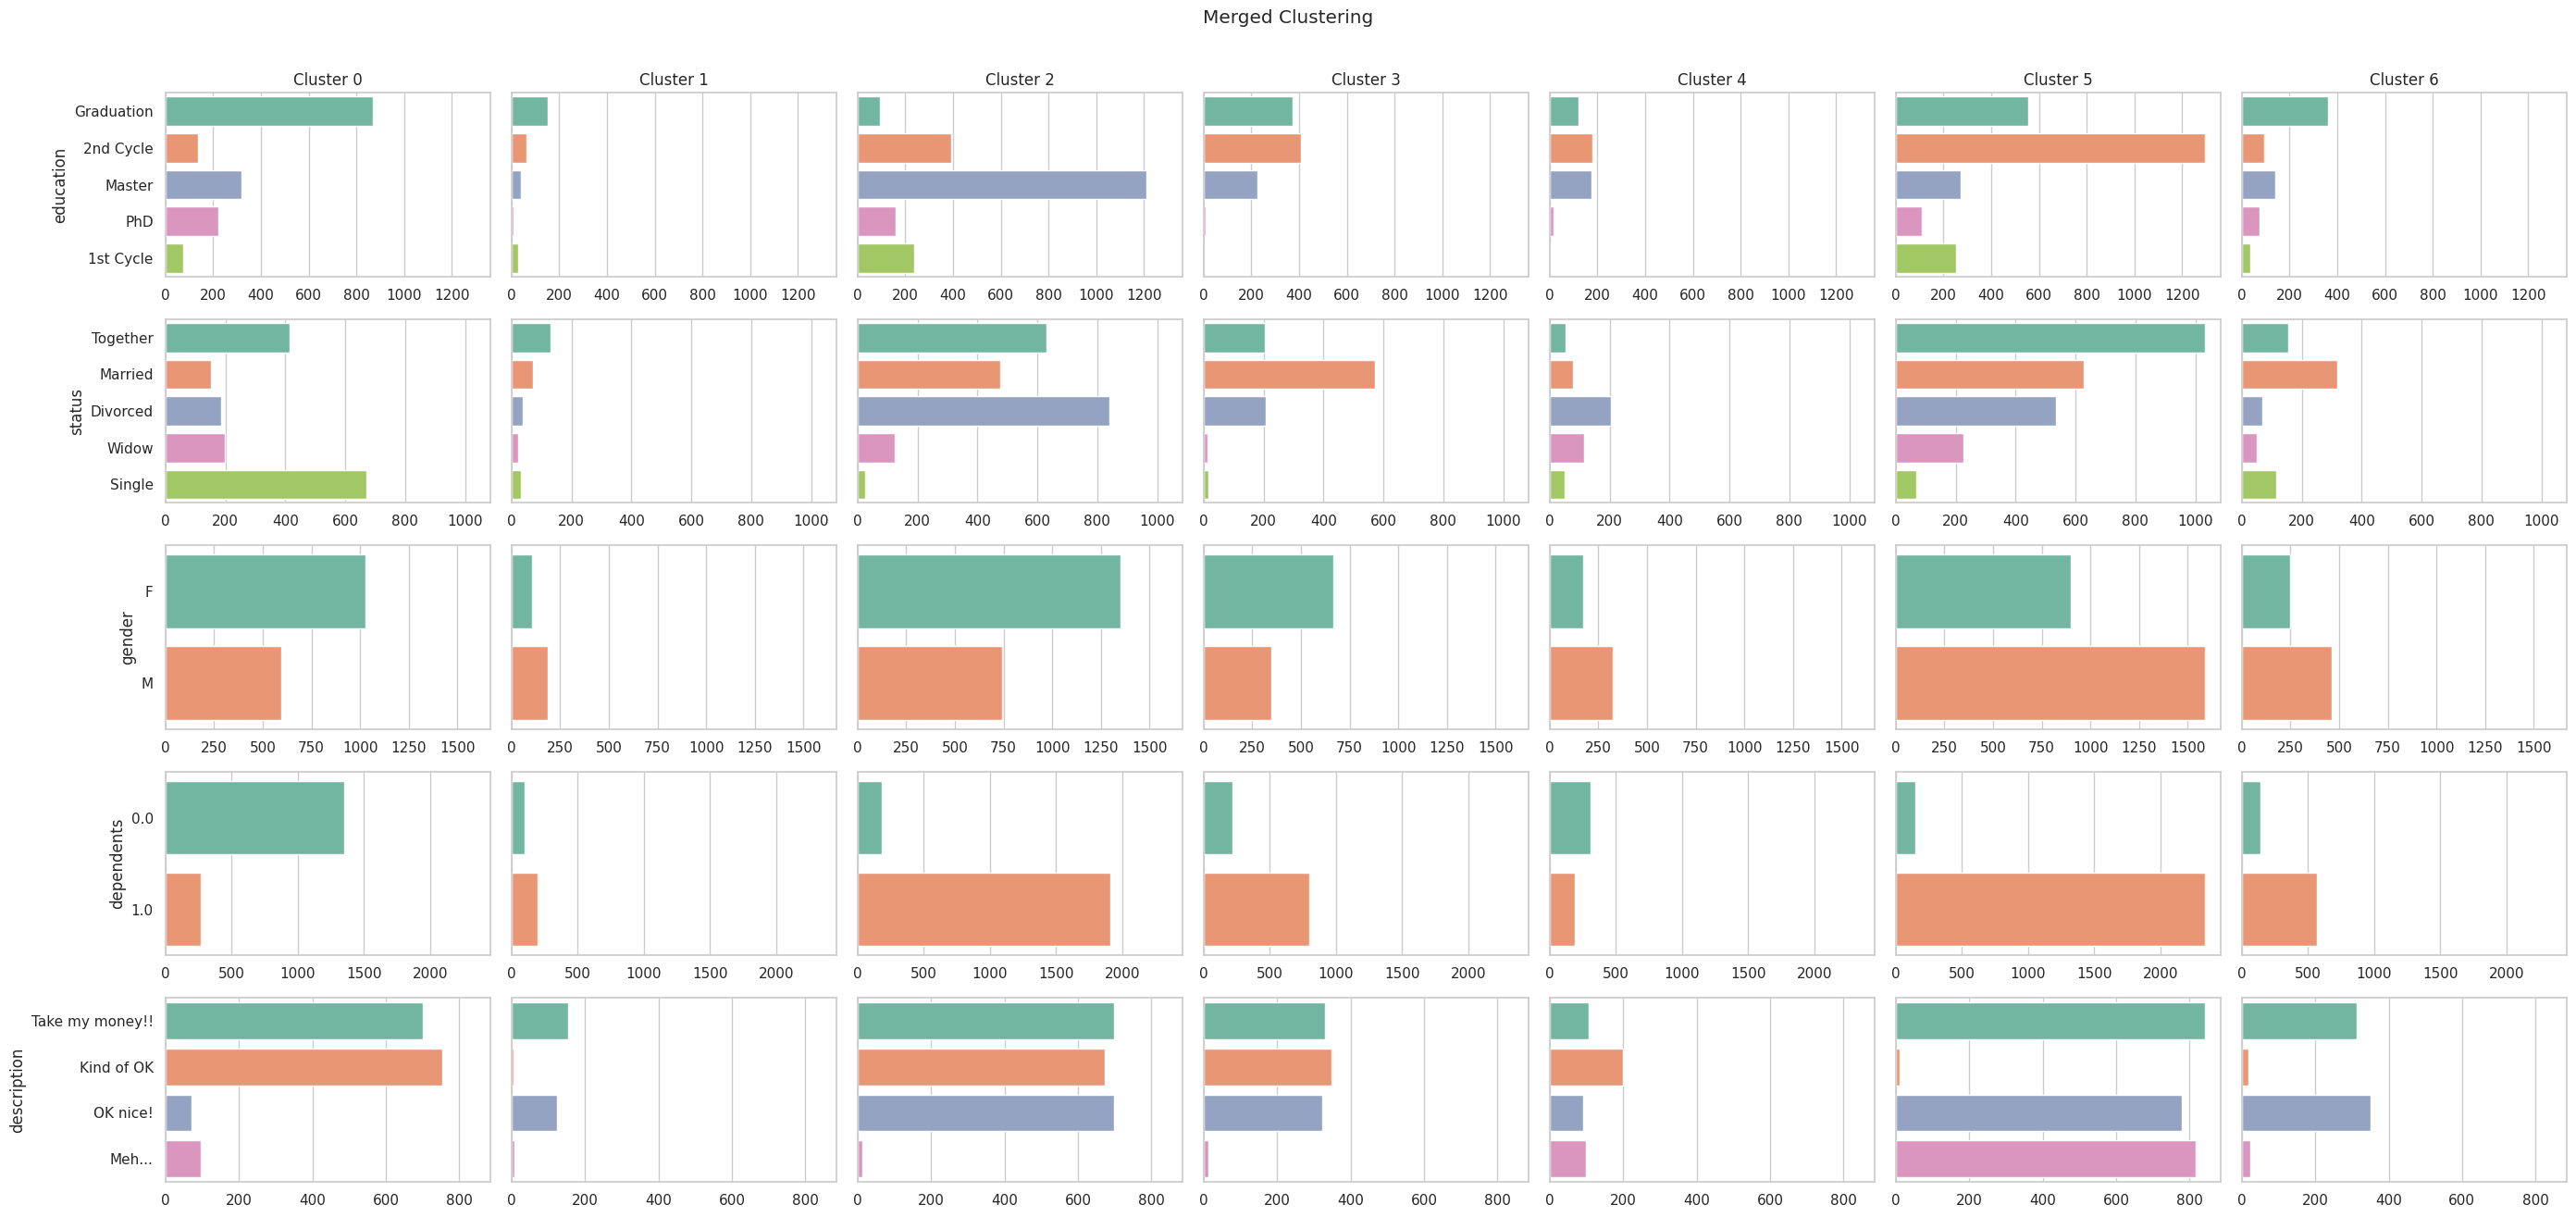

In [67]:
# Profilling each cluster (merged)
sns.set(style="whitegrid")
categorical_profiling(
    df = df[non_metric_features + labels_list],
    feats = non_metric_features,
    label = merged_label_name,
    figsize = (28, 13),
    title = "Merged Clustering"
)


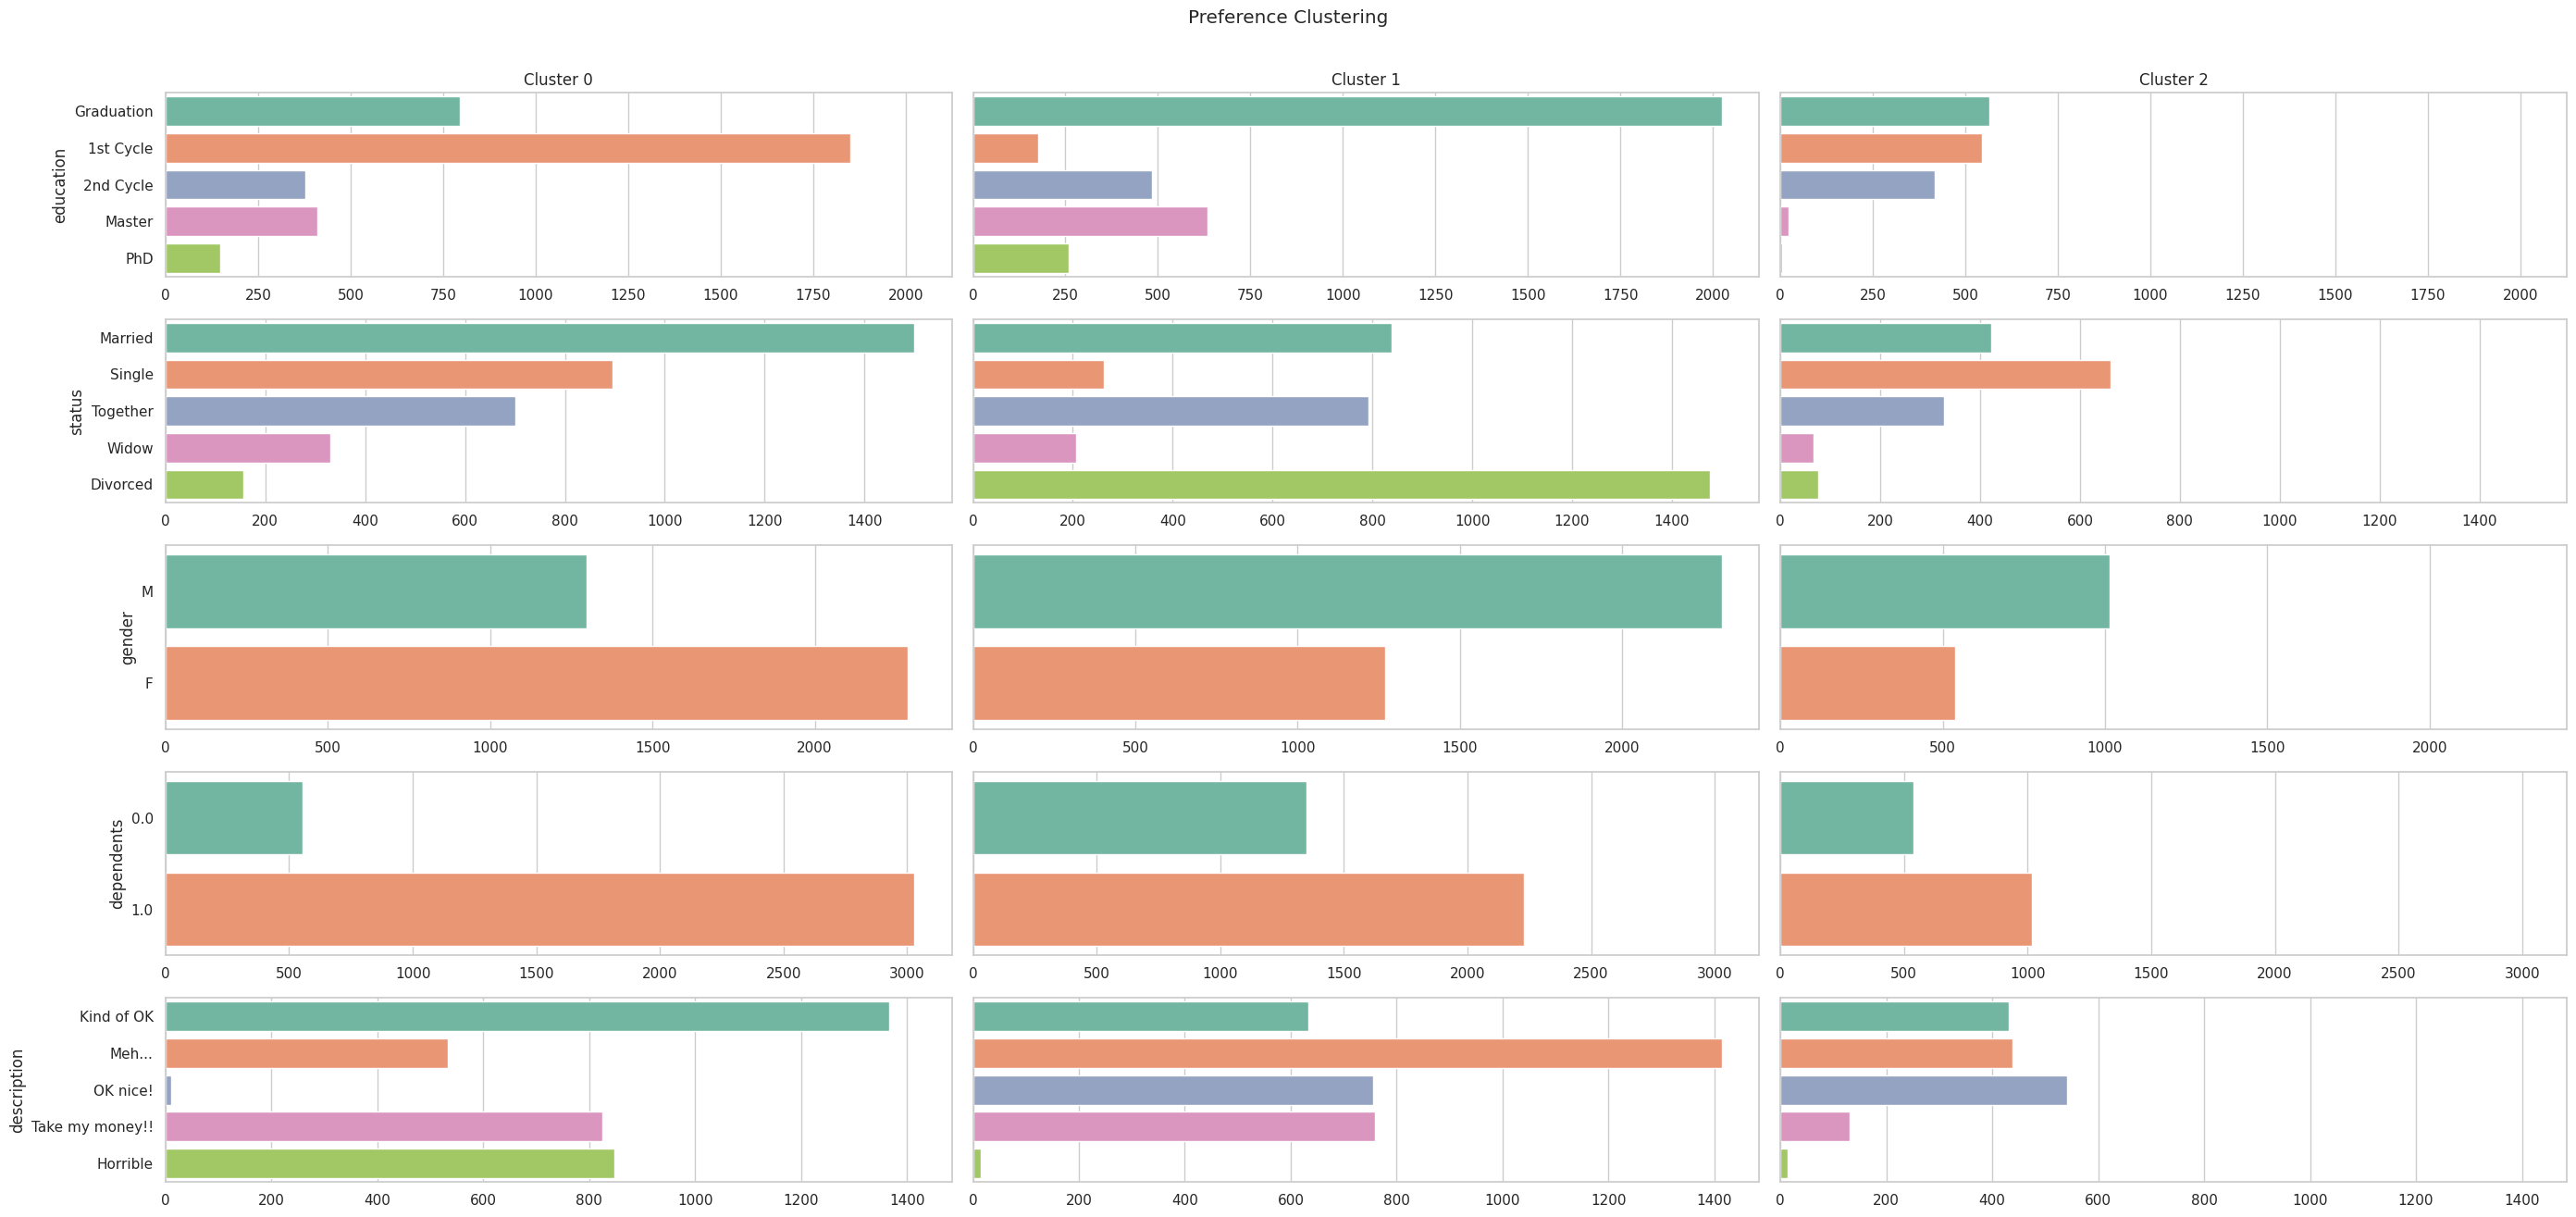

In [68]:
# Profilling each cluster (pref)
sns.set(style="whitegrid")
categorical_profiling(
    df = df[non_metric_features + labels_list],
    feats = non_metric_features,
    label = perspective_1,
    figsize = (28, 13),
    title = "Preference Clustering"
)


## Cluster Visualization using TSNE

In [69]:
df.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!', 'dbscan_labels', 'pref_labels',
       'demog_labels', 'hc_merged_labels'],
      dtype='object')

In [70]:
def plot_tsne(df, feats, label,
              cmap='tab10',
              title="t-SNE Visualization of Clustering Solution"):

  two_dim = TSNE(random_state=42).fit_transform(df[feats])
  two_dim_df = pd.DataFrame(two_dim, index=df.index)
  two_dim_df[label] = df[label]


  fig, ax= plt.subplots(figsize=(10,10))
  scatter = ax.scatter(x = two_dim_df[0],
                      y=two_dim_df[1],
                      c=two_dim_df[label],
                      s=5,
                      cmap=cmap
                      )
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.set_xticks([])
  ax.set_yticks([])

  legend1 = ax.legend(*scatter.legend_elements(),
                      loc="best", title="Cluster Labels")
  ax.add_artist(legend1)

  plt.title(title)
  plt.show()

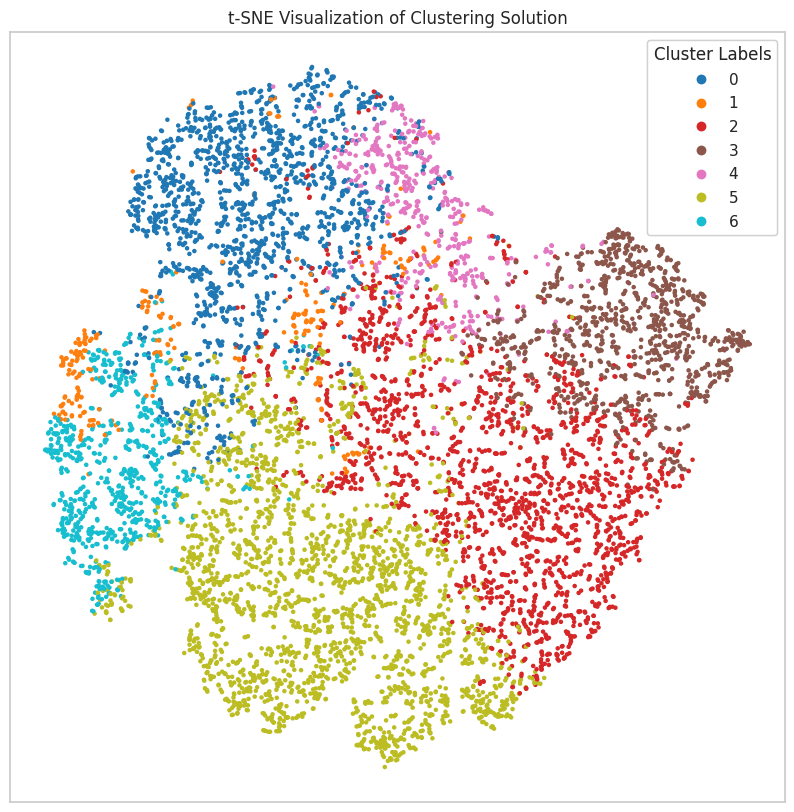

In [71]:
plot_tsne(df, metric_features, merged_label_name)

## Feature importance and reclassifying noise / outliers

### Decision Tree

In [72]:
# Preparing the data
X = df[metric_features]
y = df[merged_label_name]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fitting the decision tree
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
print("It is estimated that on average, we are able to predict {0:.2f}% of the customers correctly".format(dt.score(X_test, y_test)*100))



It is estimated that on average, we are able to predict 84.97% of the customers correctly


In [73]:
# Assessing feature importance
pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)


clothes             0.383207
spent_online        0.245097
per_net_purchase    0.203994
frq                 0.101130
small_appliances    0.032788
kitchen             0.029804
toys                0.003981
income              0.000000
rcn                 0.000000
house_keeping       0.000000
dtype: float64

In [74]:
## Remember our noise rows that we removed with DBSCAN?
## Predicting the cluster labels of the outliers

df_noise[merged_label_name] = dt.predict(df_noise[metric_features])
df_noise[metric_features + [merged_label_name]].head()

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online,hc_merged_labels
16,1.550018,2.199138,0.657173,-1.400205,-0.790228,0.502272,1.075978,3.214455,-1.041124,1.723881,0
19,0.705467,-0.640275,-0.273146,-1.704776,-0.379855,-1.165068,3.976684,3.877621,-1.473995,-0.707594,2
80,-0.409958,0.733635,1.255236,-1.226165,-0.653437,1.852024,2.381296,-0.897173,1.339671,2.022158,2
158,-1.363078,-1.189839,1.554267,-1.791796,1.261634,-1.403260,1.656119,5.071320,-0.067162,-0.985227,3
190,1.063291,-0.457087,1.521041,-1.313185,0.988052,-0.926877,1.221014,3.479722,0.095165,-0.175941,3


In [75]:
# Visualizing the decision tree
num_of_clusters = len(df[merged_label_name].unique())
cluster_names = ["Cluster {}".format(i) for i in range(num_of_clusters)]
dot_data = export_graphviz(dt, out_file=None,
                           feature_names=X.columns.to_list(),
                           filled=True,
                           rounded=True,
                           class_names=cluster_names,
                           special_characters=True)


In [76]:
### optionally save dt png
import pydotplus
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png('cluster_decision_tree.png')

## Open sidebar to download the image

True

## END of Practical Sessions

### Questions?

### How is your project?

## [OPTIONAL] Exercise

To practice your clustering skills, you can do the same exercises on a different dataset.


The Spaceship Titanic Dataset has been loaded for you in the cells below. You can find more information about this dataset from the Kaggle link.


Using this notebook as a guide, try to answer the questions that follow.


---

Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic


In [77]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/spaceship_titanic_dataset.csv")


In [78]:
## Keep only the useful features that you identified in the previous exercise

titanic_metric_features = []
titanic_non_metric_features = []


In [79]:
titanic_metric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
titanic_non_metric_features = ['HomePlanet', 'CryoSleep', 'Destination','VIP', 'Transported']


In [80]:
## Don't forget to do the preprocessing steps you performed in the previous exercise


In [81]:
titanic_df['Name'].replace(np.nan, "NO_NAME", inplace=True)
titanic_df['Cabin'].replace(np.nan, "NO_CABIN", inplace=True)

## Replace missing values using one of the methods shown previously
titanic_central = titanic_df.copy()

titanic_medians = titanic_central[titanic_metric_features].median()
titanic_modes = titanic_central[titanic_non_metric_features].mode().loc[0]

titanic_central.fillna(titanic_medians, inplace=True)
titanic_central.fillna(titanic_modes, inplace=True)

titanic_df = titanic_central.copy()


## Outlier treatment
## Use manual filters
titanic_manual_filters = (
    (titanic_df['RoomService']<=8000)
    &
    (titanic_df['FoodCourt']<=20000)
    &
    (titanic_df['ShoppingMall']<=7500)
    &
    (titanic_df['Spa']<=11000)
    &
    (titanic_df['VRDeck']<=12000)
)

titanic_df_1 = remove_outliers(titanic_df, titanic_manual_filters)
titanic_df = titanic_df_1.copy()

###########################
## with the titanic dataset we are only left with Age as a metric demographic feature
## for demo we will create a new feature "Monetary" based on the total spend on all services
## and use this as an additional feature

titanic_df['Monetary'] = titanic_df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
titanic_metric_features.append('Monetary')

##
###########################



# Use StandardScaler to scale the data
titanic_std = titanic_df.copy()
titanic_scaler = StandardScaler()
titanic_scaled_feat = titanic_scaler.fit_transform(titanic_std[titanic_metric_features])
titanic_std[titanic_metric_features] = titanic_scaled_feat

titanic_df = titanic_std.copy()

## One-hot encode categorical features
titanic_df_ohc, titanic_ohc = get_ohc_df(titanic_df, titanic_non_metric_features)

titanic_df = titanic_df_ohc.copy()

Percentage of data kept after removing outliers: 99.41


In [82]:
## Use DBSCAN to identify and separate noise rows
## making sure to use the appropriate hyperparameters such as eps and min_samples


In [83]:
dbscan_titanic = DBSCAN(eps=1.3, min_samples=12, n_jobs=4)
dbscan_titanic_labels = dbscan_titanic.fit_predict(titanic_df[titanic_metric_features])
dft_noise, dft_nonoise, dft_combined_noise = split_noise_rows(titanic_df, titanic_metric_features, dbscan_titanic)


In [84]:
dft_noise.shape, dft_nonoise.shape, dft_combined_noise.shape


((343, 23), (8299, 23), (8642, 23))

In [85]:
## Keep no noise df

In [86]:
## Keep no noise df

In [87]:
titanic_df = dft_nonoise.copy()

In [88]:
## Perform clustering using two perspectives

In [89]:
## based on the customers' preferences
titanic_pref_feats = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
ti_pers_1 = 'pref_labels'

## based on demographic + value features
titanic_demog_feats = ['Age', 'Monetary']
ti_pers_2 = 'demog_labels'

In [90]:
## Determine appropriate K for each

In [91]:
# Applying the right clustering (algorithm and number of clusters) for each perspective

In [92]:
# Choosing 4 instead of 6 here because 6 results in a lot of very small clusters
ti_kmeans_pref = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)

ti_pref_labels = ti_kmeans_pref.fit_predict(titanic_df[titanic_pref_feats])
titanic_df[ti_pers_1] = ti_pref_labels

################################

ti_kmeans_demog = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)

ti_demog_labels = ti_kmeans_demog.fit_predict(titanic_df[titanic_demog_feats])
titanic_df[ti_pers_2] = ti_demog_labels


In [93]:
## Merge the two perspectives using Manual method

In [94]:
## Map combinations of the two labels to their merged cluster label
## For example:
## pref_labels=1, demog_labels=2 => merged_label=6

def merge_mapper(df, label1, label2, feats, merged_label):
  df_ = df.copy()

  # Centroids of the concatenated cluster labels
  df_centroids = df_.groupby([label1, label2])[feats].mean()
  df_centroids[merged_label] = np.arange(df_centroids.shape[0])

  cluster_mapper = df_centroids[merged_label].to_dict()

  # Mapping the clusters on the centroids to the observations
  df_[merged_label] = df_.apply(
      lambda row: cluster_mapper[
          (row[label1], row[label2])
      ], axis=1
  )

  return df_, df_centroids


In [95]:
def manual_merge(to_merge, df, feats, label1, label2):
  """
  Merges using list of clusters given.
  The function works by looking for the cluster (target)
  that is closest to the specified cluster (source) in `to_merge`.
  Once a cluster has become a target, it will not be considered
  as a source even if it is listed in `to_merge`.

  to_merge              : list of indices of contingency table
  df                    : DataFrame
  feats                 : list of features
  label1                : name of label (contingency table rows)
  label2                : name of label (contingency table cols)
  """
  df_centroids = df.groupby([label1, label2])\
      [feats].mean()

  # Computing the euclidean distance matrix between the centroids
  euclidean = pairwise_distances(df_centroids)
  df_dists = pd.DataFrame(
      euclidean, columns=df_centroids.index, index=df_centroids.index
  )

  # Merging each low frequency clustering (source) to the closest cluster (target)

  source_target = {}
  for clus in to_merge:
      if clus not in source_target.values():
          source_target[clus] = df_dists.loc[clus].sort_values().index[1]

  df_ = df.copy()

  # Changing the labels based on source_target
  for source, target in source_target.items():
      mask = (df_[label1]==source[0]) & (df_[label2]==source[1])
      df_.loc[mask, label1] = target[0]
      df_.loc[mask, label2] = target[1]

  return df_



In [96]:
# Clusters with low frequency to be merged:
# (row,col)
ti_to_merge = [(0,0), (0,2), (1,3), (2,3)]

# Merge the low-frequency clusters
t_df_manual = manual_merge(ti_to_merge,
                           titanic_df, titanic_metric_features,
                           ti_pers_2, ti_pers_1)



In [97]:
# Still some clusters with low frequency: (1,3) got moved to the empty cluster of (0,0):
# (row,col)

ti_to_merge = [(0,0)]

# Merge the low-frequency clusters
t_df_manual = manual_merge(ti_to_merge,
                           t_df_manual, titanic_metric_features,
                           ti_pers_2, ti_pers_1)

t_df_manual_merged, t_df_manual_centroids = merge_mapper(t_df_manual,
                                                     ti_pers_1, ti_pers_2,
                                                     titanic_metric_features,
                                                     'titanic_merged_labels')

In [98]:
## Prefer to keep the manual merging

In [99]:
titanic_df = t_df_manual_merged.copy()

In [100]:
## Characterizing clusters
titanic_merged_label_name = 'titanic_merged_labels'
titanic_labels_list = [ti_pers_2, ti_pers_1, titanic_merged_label_name]


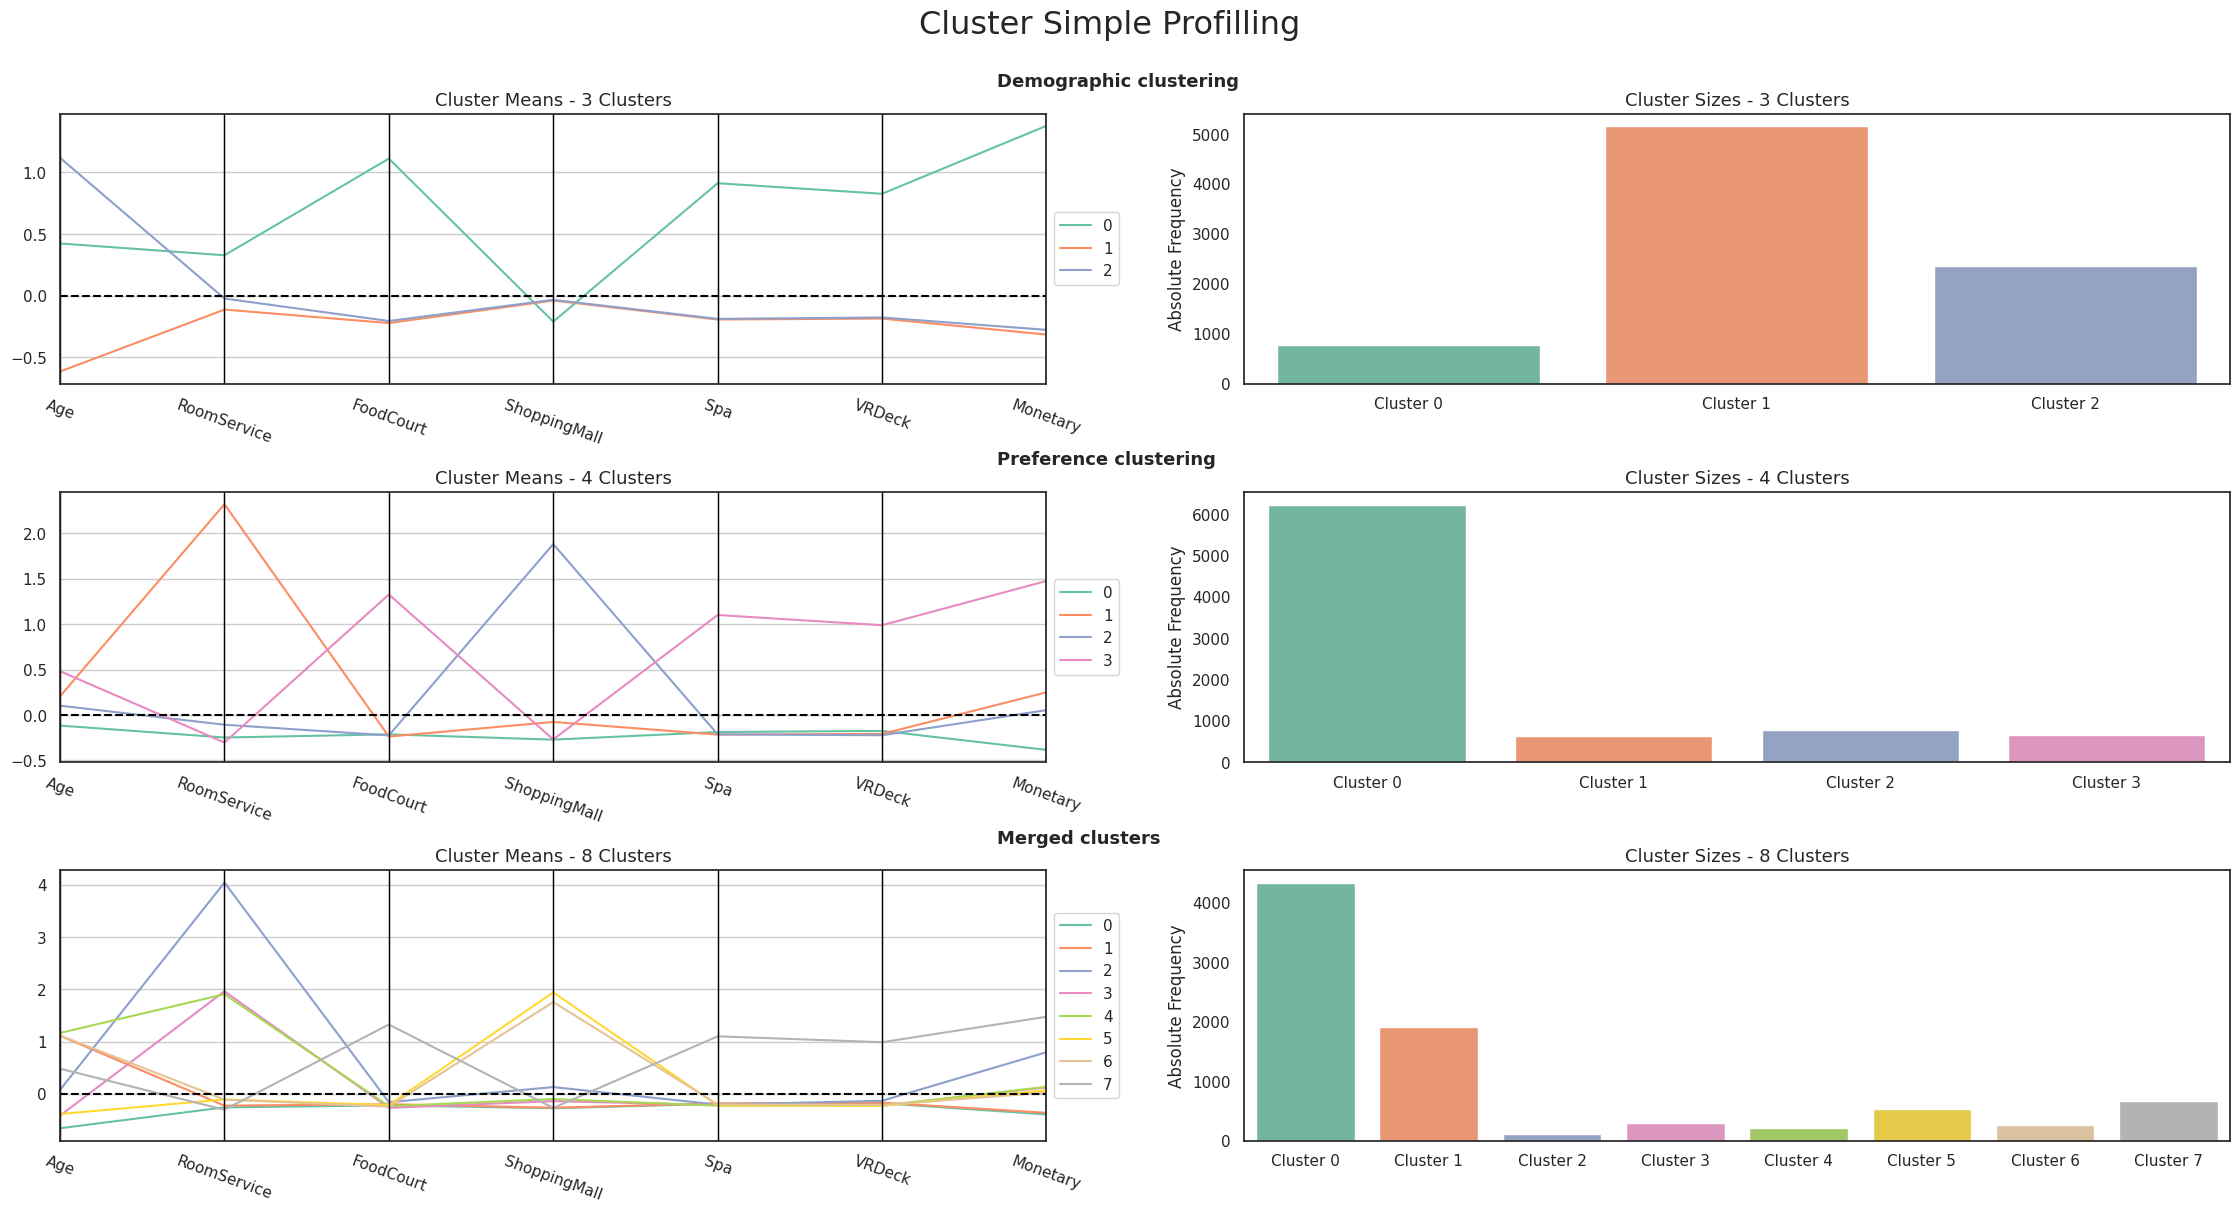

In [101]:
# Profilling each cluster (product, behavior, merged)
sns.set(style="white")
cluster_profiles(
    df = titanic_df[titanic_metric_features + titanic_labels_list],
    label_columns = titanic_labels_list,
    figsize = (28, 13),
    compar_titles = ["Demographic clustering", "Preference clustering", "Merged clusters"],
    colors='Set2'
)


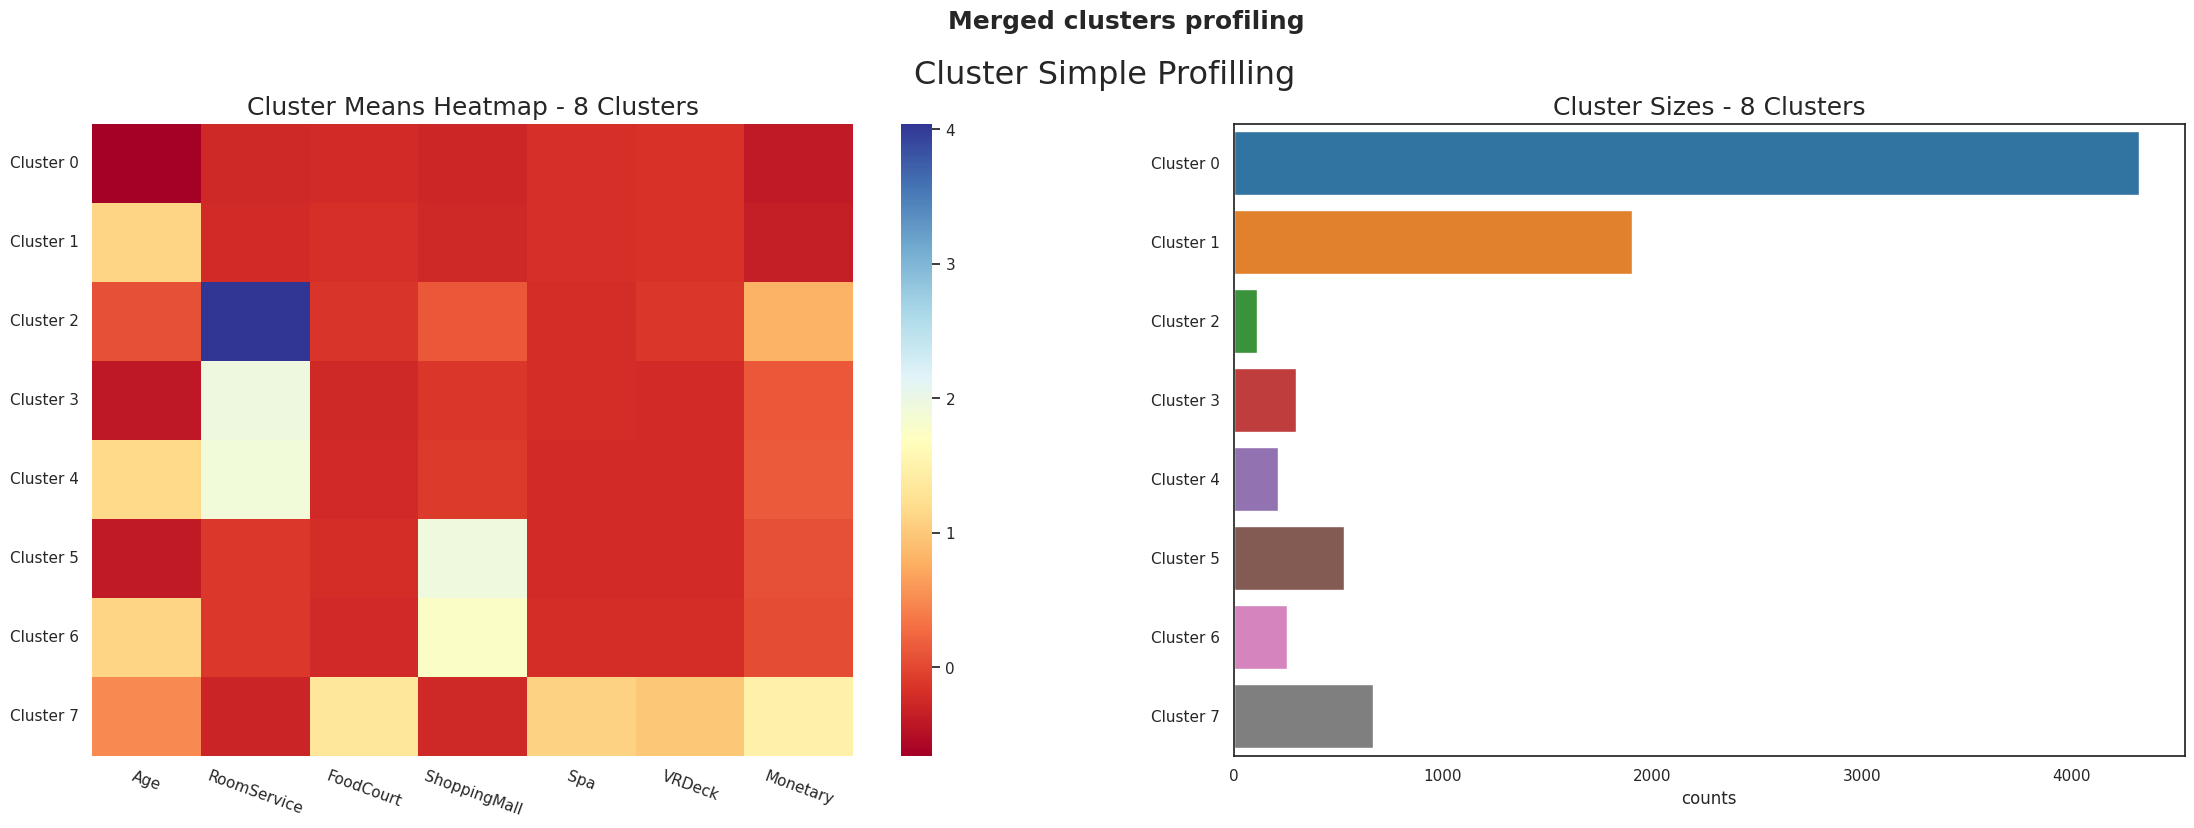

In [102]:

# Profilling each cluster (only merged)

sns.set(style="white")
cluster_heatmaps(
    df = titanic_df[titanic_metric_features + [titanic_merged_label_name]],
    label_columns = [titanic_merged_label_name],
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    bar_colors='tab10'
)

sns.set()


In [103]:
## Tabular characterization
t_scaled_feature_names = titanic_scaler.get_feature_names_out()

t_df_unscaled = titanic_df.copy()

t_df_unscaled[t_scaled_feature_names] = pd.DataFrame(titanic_scaler.inverse_transform(titanic_df[t_scaled_feature_names]),
                           index=titanic_df.index)

t_df_unscaled.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True,Transported_True,dbscan_labels,pref_labels,demog_labels,titanic_merged_labels
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,0,2,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0,0,1,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,3,0,7
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0,0,1,0
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0,0,2,1


In [104]:
t_cluster_means = get_mean_bylabel(t_df_unscaled,
                                 titanic_metric_features,
                                 titanic_merged_label_name)

t_cluster_means.style.format(precision=2).background_gradient(axis=0)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Monetary
titanic_merged_labels,,,,,,,
0,19.33,58.80,105.58,27.80,100.60,102.10,394.88
1,44.71,78.03,138.01,32.18,106.87,112.18,467.27
2,29.86,2596.39,192.42,225.21,86.44,146.02,3246.49
3,22.80,1368.75,36.59,93.87,79.82,56.29,1635.33
4,45.48,1335.84,83.39,113.46,67.46,58.70,1658.86
5,23.24,148.13,111.83,1109.39,74.59,54.77,1498.72
6,44.79,146.79,71.22,1019.47,89.20,69.78,1396.46
7,35.67,32.02,2328.01,30.36,1272.26,1211.47,4874.12


In [105]:
## Characteristics considering merged labels segmentation (non metric)
## MODE of each feature for each cluster

titanic_df.groupby([titanic_merged_label_name])[titanic_non_metric_features].agg(pd.Series.mode)


,HomePlanet,CryoSleep,Destination,VIP,Transported
titanic_merged_labels,,,,,
0,Earth,False,TRAPPIST-1e,False,True
1,Earth,True,TRAPPIST-1e,False,True
2,Mars,False,TRAPPIST-1e,False,False
3,Mars,False,TRAPPIST-1e,False,False
4,Mars,False,TRAPPIST-1e,False,False
5,Earth,False,TRAPPIST-1e,False,True
6,Earth,False,TRAPPIST-1e,False,True
7,Europa,False,TRAPPIST-1e,False,False


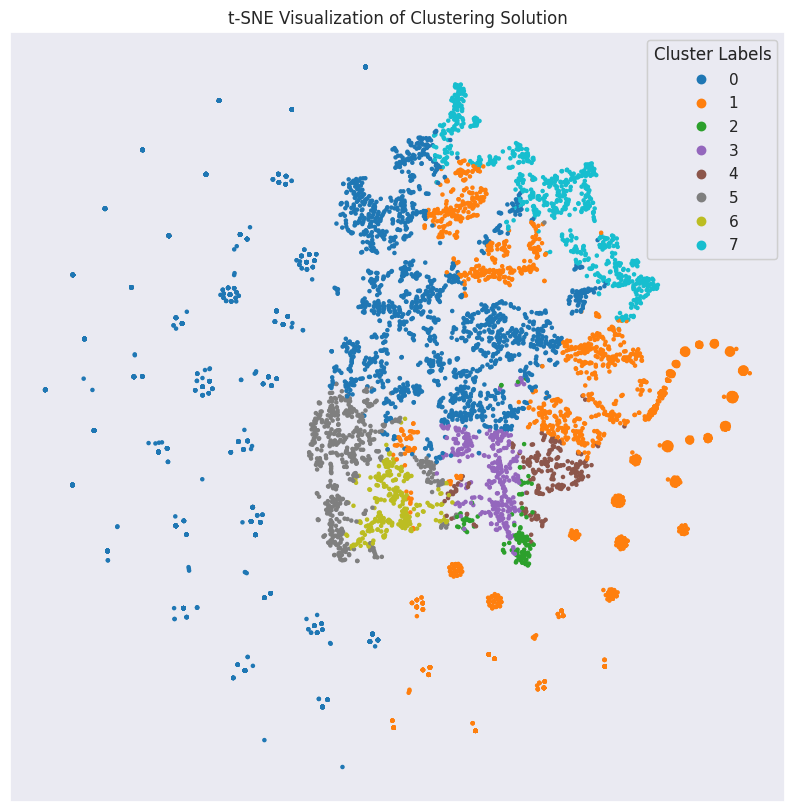

In [106]:
## TSNE Plot

plot_tsne(titanic_df, titanic_metric_features, titanic_merged_label_name)


In [107]:
# Preparing the data
t_X = titanic_df[titanic_metric_features]
t_y = titanic_df[titanic_merged_label_name]

# Splitting the data
t_X_train, t_X_test, t_y_train, t_y_test = train_test_split(
    t_X, t_y, test_size=0.2, random_state=42
)

# Fitting the decision tree
t_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
t_dt.fit(t_X_train, t_y_train)

print("It is estimated that on average, we are able to predict {0:.2f}% of the customers correctly".format(dt.score(X_test, y_test)*100))



It is estimated that on average, we are able to predict 84.97% of the customers correctly


In [108]:
# Assessing feature importance
pd.Series(t_dt.feature_importances_, index=t_X_train.columns).sort_values(ascending=False)


Age             0.395231
ShoppingMall    0.220452
RoomService     0.194818
Monetary        0.189499
FoodCourt       0.000000
Spa             0.000000
VRDeck          0.000000
dtype: float64

In [109]:
## Remember our noise rows that we removed with DBSCAN?
## Predicting the cluster labels of the outliers

dft_noise[titanic_merged_label_name] = t_dt.predict(dft_noise[titanic_metric_features])
dft_noise[titanic_metric_features + [titanic_merged_label_name]].head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Monetary,titanic_merged_labels
2,2.039434,-0.284096,2.196152,-0.330585,7.097268,-0.233451,3.774849,7
73,0.644875,-0.356986,3.772007,-0.330585,0.053854,9.868091,6.041311,7
75,0.923787,12.197036,-0.292920,-0.330585,-0.299748,-0.284984,2.532718,2
105,0.923787,3.387523,7.654568,-0.330585,1.757977,0.183021,6.093467,2
230,0.296235,-0.356986,-0.233059,1.300273,0.343566,11.191124,4.607248,6


## END of notebooks